In [0]:
from pyspark.sql.functions import *
from pyspark.sql.window import Window

customers_df = spark.read.format("delta").load(
    "/Volumes/hexa_databrick_7405612841012936/default/retail-volume/customers"
)

products_df = spark.read.format("delta").load(
    "/Volumes/hexa_databrick_7405612841012936/default/retail-volume/products"
)

orders_df = spark.read.format("delta").load(
    "/Volumes/hexa_databrick_7405612841012936/default/retail-volume/orders"
)

preferences_df = spark.read.format("delta").load(
    "/Volumes/hexa_databrick_7405612841012936/default/retail-volume/preferences"
)

In [0]:
customer_pref_df = customers_df.join(
    preferences_df,
    on="customer_id",
    how="left"
)

customer_pref_df.show()

+-----------+-------------+---------+-----------+-------------+-----------------+--------+------+
|customer_id|customer_name|     city|      state|customer_type|preferred_channel|    tier|points|
+-----------+-------------+---------+-----------+-------------+-----------------+--------+------+
|       C101| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|    Gold|  1200|
|       C102|  Priya Reddy|Bangalore|  Karnataka|      Regular|            Store|  Silver|   700|
|       C103|   Amit Kumar|   Mumbai|Maharashtra|      Regular|             NULL|    NULL|  NULL|
|       C104|  Sneha Patel|    Delhi|      Delhi|      Premium|           Online|Platinum|  2200|
|       C105|   Farhan Ali|  Chennai| Tamil Nadu|      Regular|             NULL|    NULL|  NULL|
|       C106|   Neha Singh|     Pune|Maharashtra|      Premium|             NULL|    NULL|  NULL|
|       C107|  Arjun Verma|Hyderabad|  Telangana|      Regular|             NULL|    NULL|  NULL|
|       C108|   Meer

In [0]:
orders_customer_df = orders_df.join(
    customer_pref_df,
    on="customer_id",
    how="inner"
)

orders_customer_df.show()

+-----------+--------+----------+----------+---------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+
|customer_id|order_id|product_id|order_date| quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|    tier|points|
+-----------+--------+----------+----------+---------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+
|       C101|   O1009|      P102|         1|Completed|     NULL| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|    Gold|  1200|
|       C102|   O1002|      P102|         2|Completed|     NULL|  Priya Reddy|Bangalore|  Karnataka|      Regular|            Store|  Silver|   700|
|       C103|   O1003|      P103|         3|  Pending|     NULL|   Amit Kumar|   Mumbai|Maharashtra|      Regular|             NULL|    NULL|  NULL|
|       C104|   O1010|      P101|         1|Completed|     NULL|  Sneha Patel|    Delhi|      Delhi|      

In [0]:
retail_df = orders_customer_df.join(
    products_df,
    on="product_id",
    how="inner"
)

retail_df.show()

+----------+-----------+--------+----------+---------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+------------+-----------+----------+
|product_id|customer_id|order_id|order_date| quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|    tier|points|product_name|   category|unit_price|
+----------+-----------+--------+----------+---------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+------------+-----------+----------+
|      P102|       C101|   O1009|         1|Completed|     NULL| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|    Gold|  1200|      Mobile|Electronics|     25000|
|      P102|       C102|   O1002|         2|Completed|     NULL|  Priya Reddy|Bangalore|  Karnataka|      Regular|            Store|  Silver|   700|      Mobile|Electronics|     25000|
|      P103|       C103|   O1003|         3|  Pending|     NULL|   Amit Kum

In [0]:
retail_df = retail_df.withColumn(
    "revenue",
    col("quantity") * col("unit_price")
)

In [0]:
retail_df = retail_df.withColumn(
    "order_month",
    month(to_date(col("order_date")))
)

In [0]:
orders_df.show(truncate=False)

+--------+-----------+----------+----------+---------+---------+
|order_id|customer_id|product_id|order_date|quantity |status   |
+--------+-----------+----------+----------+---------+---------+
|O1001   |C101       |P101      |2026-06-01|1        |Completed|
|O1002   |C102       |P102      |2         |Completed|NULL     |
|O1003   |C103       |P103      |3         |Pending  |NULL     |
|O1004   |C104       |P104      |2         |Completed|NULL     |
|O1005   |C105       |P105      |4         |Cancelled|NULL     |
|O1006   |C106       |P106      |1         |Completed|NULL     |
|O1007   |C107       |P107      |1         |Completed|NULL     |
|O1008   |C108       |P108      |5         |Completed|NULL     |
|O1009   |C101       |P102      |1         |Completed|NULL     |
|O1010   |C104       |P101      |1         |Completed|NULL     |
+--------+-----------+----------+----------+---------+---------+



In [0]:
orders_df.printSchema()

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_date: string (nullable = true)
 |-- quantity: string (nullable = true)
 |-- status: string (nullable = true)



In [0]:
from pyspark.sql.functions import *

orders_df = orders_df.withColumn(
    "quantity",
    when(col("quantity") == "Completed", 1)
    .when(col("quantity") == "Pending", 1)
    .when(col("quantity") == "Cancelled", 1)
    .otherwise(col("quantity"))
)

orders_df = orders_df.withColumn(
    "quantity",
    col("quantity").cast("int")
)

orders_df = orders_df.withColumn(
    "status",
    when(col("status").isNull() & (col("order_date") == "2"), "Completed")
    .when(col("status").isNull() & (col("order_date") == "3"), "Pending")
    .when(col("status").isNull() & (col("order_date") == "4"), "Completed")
    .when(col("status").isNull() & (col("order_date") == "5"), "Cancelled")
    .when(col("status").isNull() & (col("order_date") == "1"), "Completed")
    .otherwise(col("status"))
)

In [0]:
retail_df = retail_df.withColumn(
    "revenue",
    col("quantity").cast("int") *
    col("unit_price").cast("int")
)

In [0]:
retail_df = orders_customer_df.join(
    products_df,
    on="product_id",
    how="inner"
)

retail_df.show()

+----------+-----------+--------+----------+---------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+------------+-----------+----------+
|product_id|customer_id|order_id|order_date| quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|    tier|points|product_name|   category|unit_price|
+----------+-----------+--------+----------+---------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+------------+-----------+----------+
|      P102|       C101|   O1009|         1|Completed|     NULL| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|    Gold|  1200|      Mobile|Electronics|     25000|
|      P102|       C102|   O1002|         2|Completed|     NULL|  Priya Reddy|Bangalore|  Karnataka|      Regular|            Store|  Silver|   700|      Mobile|Electronics|     25000|
|      P103|       C103|   O1003|         3|  Pending|     NULL|   Amit Kum

In [0]:
retail_df.createOrReplaceTempView("retail")

In [0]:
spark.sql("""
SELECT city,
COUNT(*) customer_count
FROM retail
GROUP BY city
""").show()

+---------+--------------+
|     city|customer_count|
+---------+--------------+
|    Delhi|             2|
|  Chennai|             1|
|    Kochi|             1|
|Hyderabad|             3|
|Bangalore|             1|
|     Pune|             1|
|   Mumbai|             1|
+---------+--------------+



In [0]:
spark.sql("""
SELECT category,
COUNT(*) product_count
FROM retail
GROUP BY category
""").show()

+-----------+-------------+
|   category|product_count|
+-----------+-------------+
|Electronics|            5|
|  Furniture|            2|
|    Fashion|            3|
+-----------+-------------+



In [0]:
spark.sql("""
SELECT customer_name,
customer_type
FROM retail
WHERE customer_type='Premium'
""").show()

+-------------+-------------+
|customer_name|customer_type|
+-------------+-------------+
| Rahul Sharma|      Premium|
|  Sneha Patel|      Premium|
|   Neha Singh|      Premium|
|   Meera Nair|      Premium|
| Rahul Sharma|      Premium|
|  Sneha Patel|      Premium|
+-------------+-------------+



In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import *

window_spec = Window.orderBy("customer_name")

retail_df.withColumn(
    "row_number",
    row_number().over(window_spec)
).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+-----------+--------+----------+---------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+------------+-----------+----------+----------+
|product_id|customer_id|order_id|order_date| quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|    tier|points|product_name|   category|unit_price|row_number|
+----------+-----------+--------+----------+---------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+------------+-----------+----------+----------+
|      P103|       C103|   O1003|         3|  Pending|     NULL|   Amit Kumar|   Mumbai|Maharashtra|      Regular|             NULL|    NULL|  NULL|       Chair|  Furniture|      7000|         1|
|      P107|       C107|   O1007|         1|Completed|     NULL|  Arjun Verma|Hyderabad|  Telangana|      Regular|             NULL|    NULL|  NULL|          TV|Electronics|     45000|         2|
|      P105|       C

In [0]:
window_spec = Window.orderBy("product_name")

retail_df.withColumn(
    "dense_rank",
    dense_rank().over(window_spec)
).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+-----------+--------+----------+---------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+------------+-----------+----------+----------+
|product_id|customer_id|order_id|order_date| quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|    tier|points|product_name|   category|unit_price|dense_rank|
+----------+-----------+--------+----------+---------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+------------+-----------+----------+----------+
|      P108|       C108|   O1008|         5|Completed|     NULL|   Meera Nair|    Kochi|     Kerala|      Premium|       Mobile App|    Gold|  1500|         Bag|    Fashion|      3000|         1|
|      P103|       C103|   O1003|         3|  Pending|     NULL|   Amit Kumar|   Mumbai|Maharashtra|      Regular|             NULL|    NULL|  NULL|       Chair|  Furniture|      7000|         2|
|      P101|       C

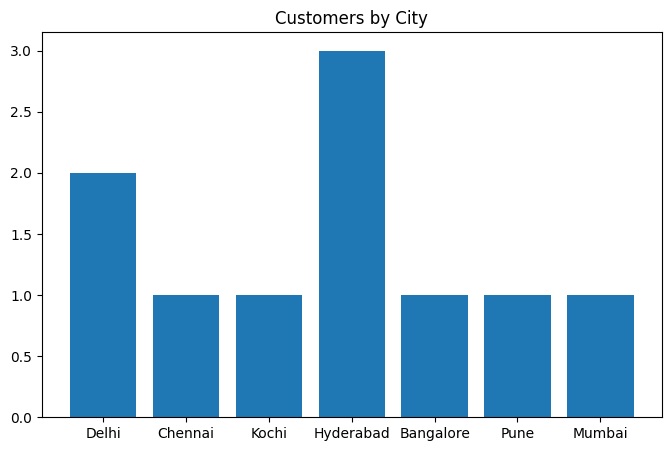

In [0]:
import matplotlib.pyplot as plt

city_df = retail_df.groupBy("city").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_df["city"], city_df["count"])
plt.title("Customers by City")
plt.show()

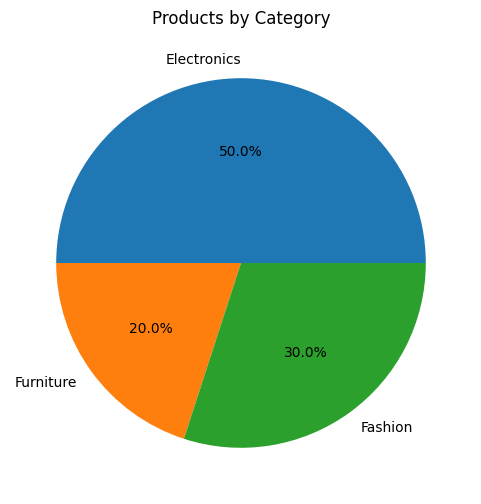

In [0]:
category_df = retail_df.groupBy("category").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(
    category_df["count"],
    labels=category_df["category"],
    autopct="%1.1f%%"
)
plt.title("Products by Category")
plt.show()

In [0]:
retail_df.write \
.mode("overwrite") \
.format("delta") \
.save("/Volumes/hexa_databrick_7405612841012936/default/retail-volume/final_retail")

In [0]:
spark.sql("""
DESCRIBE HISTORY delta.`/Volumes/hexa_databrick_7405612841012936/default/retail-volume/final_retail`
""").show(truncate=False)

+-------+-------------------+---------------+-------------------------------------------------------+---------+------------------------------------------------------------+----+------------------+------------------------------------+------------------------+-----------+-----------------+-------------+----------------------------------------------------------------------------------------------------------------------------------------+------------+------------------------------------------+
|version|timestamp          |userId         |userName                                               |operation|operationParameters                                         |job |notebook          |queryHistoryStatementId             |clusterId               |readVersion|isolationLevel   |isBlindAppend|operationMetrics                                                                                                                        |userMetadata|engineInfo                                |
+-------

In [0]:
spark.read \
.format("delta") \
.option("versionAsOf",0) \
.load("/Volumes/hexa_databrick_7405612841012936/default/retail-volume/final_retail") \
.show()

+----------+-----------+--------+----------+---------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+------------+-----------+----------+
|product_id|customer_id|order_id|order_date| quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|    tier|points|product_name|   category|unit_price|
+----------+-----------+--------+----------+---------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+------------+-----------+----------+
|      P102|       C101|   O1009|         1|Completed|     NULL| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|    Gold|  1200|      Mobile|Electronics|     25000|
|      P102|       C102|   O1002|         2|Completed|     NULL|  Priya Reddy|Bangalore|  Karnataka|      Regular|            Store|  Silver|   700|      Mobile|Electronics|     25000|
|      P103|       C103|   O1003|         3|  Pending|     NULL|   Amit Kum